### **EX NO 6 - IMPLEMENTATION OF LONG SHORT-TERM MEMORY (LSTM) FOR SENTIMENT ANALYSIS**

***- Sreenidhi S (24BAD114)***

**AIM**

To implement a Long Short-Term Memory (LSTM) neural network for sentiment analysis and classify textual data into appropriate sentiment categories based on the learned linguistic patterns.


**PART A: DATASET PREPARATION**

**Perform the following tasks:**

•	Load a suitable sentiment analysis dataset such as the IMDB Movie Reviews dataset.

•	Explore the dataset and examine sample reviews and their corresponding sentiment labels.

•	Identify the positive and negative sentiment classes.

•	Perform basic text preprocessing such as converting text to lowercase, if required.

•	Remove unnecessary characters or symbols, if required.

•	Tokenize the reviews into words.

•	Build a vocabulary and assign unique integer indices to words.

•	Convert the text reviews into numerical sequences.

•	Apply sequence padding to obtain inputs of equal length.

•	Split the prepared dataset into training and validation/testing datasets.


In [3]:
print("Sreenidhi S - 24BAD114")

import re
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# 1. Load the IMDB Movie Reviews dataset
vocab_size = 10000
max_length = 200
(X_train_original, y_train_original), (X_test_original, y_test) = (
    imdb.load_data(num_words=vocab_size)
)

print("\n1. DATASET INFORMATION")
print("Training reviews:", len(X_train_original))
print("Testing reviews:", len(X_test_original))
print("Vocabulary limit:", vocab_size)

# 2. Identify positive and negative sentiment classes
print("\n2. SENTIMENT CLASSES")
print("0 = Negative")
print("1 = Positive")
print("\nTraining class distribution:")
print(pd.Series(y_train_original).value_counts().sort_index())

# 3. Convert numerical reviews into readable text
word_index = imdb.get_word_index()
reverse_word_index = {
    index + 3: word
    for word, index in word_index.items()
}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(sequence):
    return " ".join(
        reverse_word_index.get(index, "<UNK>")
        for index in sequence
    )

train_reviews = [
    decode_review(sequence)
    for sequence in X_train_original
]

test_reviews = [
    decode_review(sequence)
    for sequence in X_test_original
]

# 4. Explore sample reviews and labels
print("\n3. SAMPLE REVIEWS")

for i in range(3):
    sentiment = "Positive" if y_train_original[i] == 1 else "Negative"
    print(f"\nReview {i + 1}")
    print("Sentiment:", sentiment)
    print(train_reviews[i][:300])

# 5. Basic text preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

clean_train_reviews = [
    clean_text(review) for review in train_reviews
]

clean_test_reviews = [
    clean_text(review) for review in test_reviews
]

print("\n4. PREPROCESSING")
print("Original review:", train_reviews[0][:200])
print("Cleaned review:", clean_train_reviews[0][:200])

# 6. Tokenize reviews and build vocabulary
tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(clean_train_reviews)

print("\n5. TOKENIZATION AND VOCABULARY")
print("Total words in tokenizer:", len(tokenizer.word_index))
print("Vocabulary limit used:", vocab_size)
print("Sample word indices:")

for word, index in list(tokenizer.word_index.items())[:10]:
    print(word, ":", index)

# 7. Convert text reviews into numerical sequences
X_train_sequences = tokenizer.texts_to_sequences(clean_train_reviews)
X_test_sequences = tokenizer.texts_to_sequences(clean_test_reviews)

print("\n6. NUMERICAL SEQUENCES")
print("First review sequence:", X_train_sequences[0][:20])

# 8. Apply sequence padding
X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("\n7. SEQUENCE PADDING")
print("Training data shape:", X_train_padded.shape)
print("Testing data shape:", X_test_padded.shape)

# 9. Split training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_padded,
    y_train_original,
    test_size=0.2,
    random_state=42,
    stratify=y_train_original
)

print("\n8. FINAL DATA SPLIT")
print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Testing samples:", X_test_padded.shape[0])

print("\nTraining shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Testing shape:", X_test_padded.shape)



Sreenidhi S - 24BAD114

1. DATASET INFORMATION
Training reviews: 25000
Testing reviews: 25000
Vocabulary limit: 10000

2. SENTIMENT CLASSES
0 = Negative
1 = Positive

Training class distribution:
0    12500
1    12500
Name: count, dtype: int64

3. SAMPLE REVIEWS

Review 1
Sentiment: Positive
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the

Review 2
Sentiment: Negative
<START> big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the worst ever made the plot is paper thin and ridiculous the acting is an abomination the script is co

Review 3
Sentiment: Negative
<START> this has to be one of the worst films

**PART B: IMPLEMENTING THE LSTM MODEL**

**Perform the following tasks:**

•	Create an Embedding layer to convert words into dense vector representations.

•	Add an LSTM layer to learn long-term sequential dependencies in the reviews.

•	Add a Dense output layer for sentiment classification.

•	Use an appropriate activation function such as Sigmoid for binary sentiment classification.

•	Compile the model using an appropriate optimizer and loss function.

•	Display the model architecture and model summary.


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Define model parameters
vocab_size = 10000
max_length = 200
embedding_dim = 128
lstm_units = 64

# Create the LSTM model
model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        mask_zero=True
    ),
    LSTM(lstm_units),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
model.build(input_shape=(None, max_length))

print("\nLSTM MODEL SUMMARY")
model.summary()


LSTM MODEL SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

**PART C: MODEL TRAINING AND PERFORMANCE EVALUATION**

**Perform the following tasks:**

•	Train the LSTM model using the prepared training dataset.

•	Validate the model using the validation dataset.

•	Record:

o	Training accuracy

o	Validation accuracy

o	Training loss

o	Validation loss

•	Evaluate the trained model on the test dataset.

•	Calculate suitable evaluation metrics such as:

o	Accuracy

o	Precision

o	Recall

o	F1-score

•	Generate a confusion matrix to analyze the classification performance.

•	Visualize:

o	Accuracy vs. Epoch

o	Loss vs. Epoch


**Train LSTM Model**

In [5]:
import time
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss stops improving
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

# Train the model
start_time = time.time()

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

training_time = time.time() - start_time

print(f"\nTraining time: {training_time:.2f} seconds")
print("\nTraining completed successfully!")

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 90s 555ms/step - accuracy: 0.7603 - loss: 0.4914 - val_accuracy: 0.8510 - val_loss: 0.3664
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 111s 704ms/step - accuracy: 0.8910 - loss: 0.2800 - val_accuracy: 0.8398 - val_loss: 0.4084
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 72s 460ms/step - accuracy: 0.9147 - loss: 0.2329 - val_accuracy: 0.8440 - val_loss: 0.3711

Training time: 272.89 seconds

Training completed successfully!


**Evaluate on Test Dataset**

In [7]:
# Evaluate the trained model
test_loss, test_accuracy = model.evaluate(
    X_test_padded,
    y_test,
    verbose=1
)

print("\nTEST RESULTS")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy Percentage: {test_accuracy * 100:.2f}%")


782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.8464 - loss: 0.3675

TEST RESULTS
Test Loss: 0.3675
Test Accuracy: 0.8464
Test Accuracy Percentage: 84.64%


**Calculate Confusion Matrix and Evaluation Metrics**

EVALUATION METRICS
----------------------------------------
Accuracy : 0.8464
Precision: 0.8377
Recall   : 0.8591
F1-score : 0.8483

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.83      0.84     12500
    Positive       0.84      0.86      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



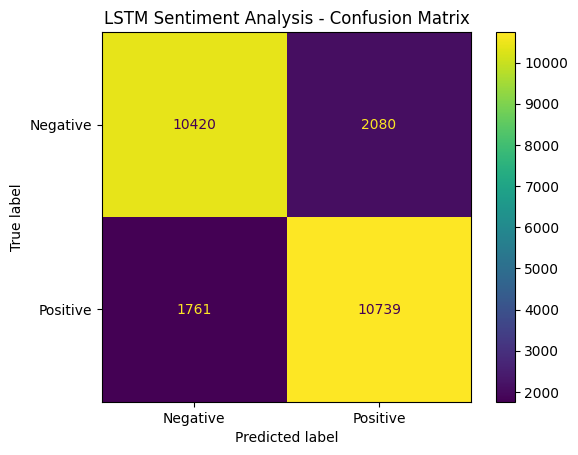

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Generate predictions for the test dataset
y_probability = model.predict(
    X_test_padded,
    verbose=0
).ravel()

y_pred = (y_probability >= 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("EVALUATION METRICS")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"],
    zero_division=0
))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

display.plot(values_format="d")
plt.title("LSTM Sentiment Analysis - Confusion Matrix")
plt.show()

**Plot accuracy and loss**

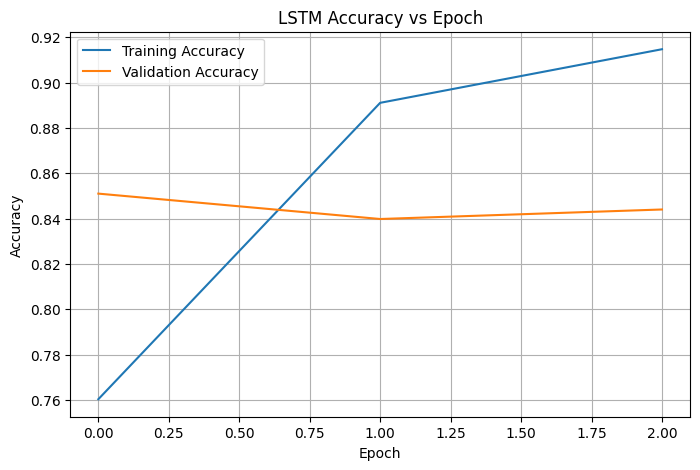

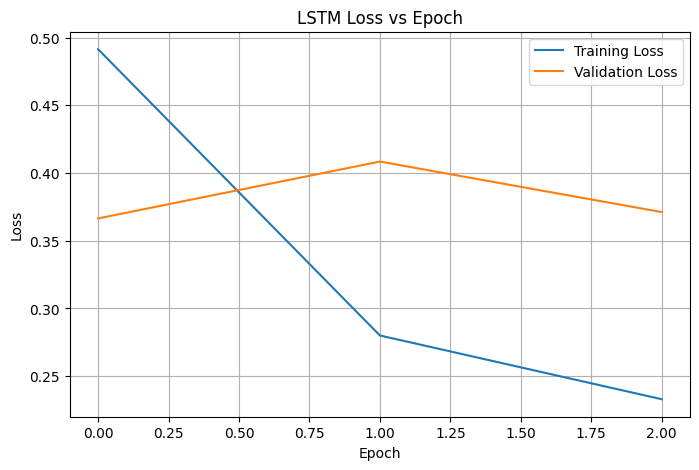

In [9]:
import matplotlib.pyplot as plt

# Accuracy vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

# Loss vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

**PART D: SENTIMENT PREDICTION AND DEEP LEARNING EXPERIMENT MANAGEMENT**

**Perform the following tasks:**

•	Provide new movie-review sentences as input to the trained LSTM model.

•	Preprocess and tokenize the input text using the same vocabulary used during training.

•	Apply sequence padding to the input text.

•	Predict the sentiment using the trained LSTM model.

•	Classify the input as Positive or Negative based on the predicted probability.

•	Provide multiple review samples with different sentiments.

•	Compare the predicted sentiment with the actual/expected sentiment.

•	Analyze the coherence and correctness of the model predictions.

•	Document the observations and upload the notebook to GitHub.


In [11]:
import re
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Preprocess a new review using the SAME tokenizer from Part A
def preprocess_new_review(review):
    review = review.lower()
    review = re.sub(r"<.*?>", " ", review)
    review = re.sub(r"[^a-z\s]", " ", review)
    review = re.sub(r"\s+", " ", review).strip()

    # Convert words into integer sequences
    sequence = tokenizer.texts_to_sequences([review])

    # Apply the same padding length used in Part A
    padded_sequence = pad_sequences(
        sequence,
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

    return padded_sequence

# Predict sentiment for a new review
def predict_sentiment(review):
    processed_review = preprocess_new_review(review)

    # Predict probability of positive sentiment
    probability = float(
        model.predict(processed_review, verbose=0)[0][0]
    )

    sentiment = "Positive" if probability >= 0.5 else "Negative"

    return sentiment, probability

# Test reviews with expected sentiments
review_samples = [
    {
        "review": "This movie was fantastic and the acting was excellent.",
        "expected": "Positive"
    },
    {
        "review": "The movie was boring and I did not enjoy it.",
        "expected": "Negative"
    },
    {
        "review": "Amazing story, wonderful performances, and great direction.",
        "expected": "Positive"
    },
    {
        "review": "Terrible film with a weak story and disappointing acting.",
        "expected": "Negative"
    },
    {
        "review": "The movie was okay, but it was not very memorable.",
        "expected": "Negative"
    }
]

# Display prediction results
results = []

for sample in review_samples:
    review = sample["review"]
    expected = sample["expected"]

    predicted, probability = predict_sentiment(review)

    results.append({
        "Review": review,
        "Expected Sentiment": expected,
        "Predicted Sentiment": predicted,
        "Positive Probability": round(probability, 4),
        "Correct": predicted == expected
    })

results_df = pd.DataFrame(results)

print("\nSENTIMENT PREDICTION RESULTS")
from IPython.display import display as show_table
show_table(results_df)

# Calculate prediction agreement with expected labels
correct_predictions = sum(row["Correct"] for row in results)
total_predictions = len(results)

print("\nTotal reviews:", total_predictions)
print("Matching predictions:", correct_predictions)
print(
    "Prediction agreement:",
    f"{correct_predictions / total_predictions * 100:.2f}%"
)


SENTIMENT PREDICTION RESULTS


,Review,Expected Sentiment,Predicted Sentiment,Positive Probability,Correct
0,This movie was fantastic and the acting was ex...,Positive,Positive,0.7828,True
1,The movie was boring and I did not enjoy it.,Negative,Negative,0.3422,True
2,"Amazing story, wonderful performances, and gre...",Positive,Positive,0.8887,True
3,Terrible film with a weak story and disappoint...,Negative,Negative,0.1019,True
4,"The movie was okay, but it was not very memora...",Negative,Negative,0.4125,True



Total reviews: 5
Matching predictions: 5
Prediction agreement: 100.00%
